In [4]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
# jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov






1 1


In [5]:
import pickle as pk
import dill as dill
import numpy as np
import matplotlib.pyplot as pl
import jax.numpy as jnp
pl.rc('text', usetex=True)
%matplotlib inline
import os

import getdist
from getdist import plots, MCSamples




def get_MC_samps(fname, param_acorr='sigma8', true_val=0.8, ess_thresh = 100, acorr_min=0.035, acorr_max = 0.05, nchains = 96, ind_frac_rm = 0.0, names=None, labels=None):
    df = pk.load(open(fname,'rb'))
    sig8 = df[param_acorr]
    
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance, effective_sample_size
    
    # acorr = autocorrelation(sig8_rs, axis=1)
    # ind_del = []
    # for ji in range(acorr.shape[0]):
    #     if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
    #         ind_del.append(ji)    

    ess_per_chain = effective_sample_size(jnp.asarray(sig8_rs))
    
    ind_del = []
    for jc in range(nchains):
        ess_jc = effective_sample_size(jnp.asarray(sig8_rs)[jc,:][None,:])
        if ess_jc < ess_thresh:
            ind_del.append(jc)  
        else:
            if np.abs(np.mean(sig8_rs[jc,:]) - true_val)/np.std(sig8_rs[jc,:]) > 5:
                ind_del.append(jc)      
            
    
    ind_del = np.array(ind_del)    
        
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    if names is None:
        names = keys
        indsel_names = np.arange(len(names))
    else:
        indsel_names = []
        for name in names:
            indsel_names.append(keys.index(name))
    
    
    save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
    labels_all = {'A_IA':r'$A_{\rm IA}$',
     'Ob0':r'$\Omega_b$',
     'Om0':r'$\Omega_{\rm m}$',
     'eta_IA':r'$\eta_{\rm IA}$',
     'log10_Mc0':r'$\log(M_c)$',
     'theta_co_0':r'$\theta_{\rm co, 0}$',
     'gamma_rhogas':r'$\gamma$',
     'nu_z':r'$\nu_z$',
     'h':r'$h$',
     'ns':r'$n_s$',
     'mu_beta':r'$\mu_{\beta}$',
     'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
     'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
     'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
     'log10_Mc0':r'$\log(M_c)$',
        'delta_rhogas':r'$\delta$',
        'gamma_rhogas':r'$\gamma$',
     'sigma8':r'$\sigma_8$',
     'theta_ej_0':r'$\theta_{\rm ej, 0}$',
     'S8':r'$S_8$',
     'alpha_nt':r'$\alpha_{\rm nt}$',
     'alpha_ky':r'$\alpha_{\rm ky}$',
     'alpha_kk':r'$\alpha_{\rm kk}$',
    'Delta_z_bias_array_0':r'$\Delta z_1$',
     'Delta_z_bias_array_1':r'$\Delta z_2$',
     'Delta_z_bias_array_2':r'$\Delta z_3$',
     'Delta_z_bias_array_3':r'$\Delta z_4$',
     'mult_shear_bias_array_0':r'$m_1$',
     'mult_shear_bias_array_1':r'$m_2$',
     'mult_shear_bias_array_2':r'$m_3$',
     'mult_shear_bias_array_3':r'$m_4$',
    'alphasat_Nsat':r'$\alpha_{\rm sat}$',
    'beta_a_fshmr':r'$\beta^{\rm galaxy}_{\rm z}$',
    'beta_fshmr':r'$\beta^{\rm galaxy}_{\rm 0}$',
    'delta_a_fshmr':r'$\delta^{\rm galaxy}_{\rm z}$',
    'delta_fshmr':r'$\delta^{\rm galaxy}_{\rm 0}$',
    'log10M1_a_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm z}$',
    'log10M1_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm 0}$',
    'siglogMstar_Ncen':r'$\sigma_{\log M^{\rm galaxy}_{\star}}$',
    }
    
    if labels is None:
        labels = []
        
        for key in keys:
            if key in labels_all.keys():
                labels.append(labels_all[key])
            else:
                labels.append(r'm')
    
    
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    # print(samps.shape, samps_sel.shape)
    # from numpyro.diagnostics import gelman_rubin, effective_sample_size, print_summary
    # ind_gr = ind_sigma8
    # gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
    print(samps.shape)
    
    samples = MCSamples(samples=samps[:,indsel_names],names = names, labels = labels)
    # marge = samples.getMargeStats()
    pars_all = samples.getParamNames().getRunningNames()
    om_index = pars_all.index('Om0')
    sig8_index = pars_all.index('sigma8')
    FoM_Om_sig8 = 1/np.sqrt(np.linalg.det(samples.getCov(pars=[om_index,sig8_index])))

    return samples, keys





In [6]:
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/inference/'

# probes_forecast = 'kk,gg,gk'
# probes_forecast = 'kk,gg,gk,ge'
# probes_forecast = 'ky,kk,gg,gy,gk,ge'

# probes_forecast_all = [ 'kk,gg,gk', 'kk,gg,gk,ge', 'ky,kk,gg,gy,gk,ge']
probes_forecast_all = [ 'kk,gg,gk', 'ky,kk,gg,gy,gk,ge']
DeltaP_mean_all = {}
DeltaP_std_all = {}
fb_mean_all = {}
fb_std_all = {}
for probes_forecast in probes_forecast_all:
    probes_forecast = probes_forecast.split(',')
    probes_forecast_all_str = '_'.join(probes_forecast)
    scval = 4000

    fname = ldir + f'infer_v5_{probes_forecast_all_str}_scval_{scval}_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_False_nsel_1024.pkl'
    # fname = ldir + 'infer_v5_gk_ge_scval_4000_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_True_nsel_1024.pkl'
    df = pk.load(open(fname, 'rb'))
    # df.keys()
    # df['rho_b_model_all_samp'].shape
    r_array = df['r_array']
    M_array = df['M_array']
    k_array = df['k_array']
    Pmm_ratio_all_samp = df['Pmm_ratio_all_samp']
    Y_M_model_all_samp = df['Y_M_model_all_samp']
    fb_M_model_all_samp = df['fb_M_model_all_samp']

    # Pmm_ratio_all_samp.shape
    Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
    Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)
    indsel = np.argmin(np.abs(k_array - 0.5))
    # print(k_array[indsel])
    # print(indsel)
    # print(Pmin[indsel], Pmax[indsel])

    Pmin = Pmin[indsel] - 1
    Pmax = Pmax[indsel] - 1
    DeltaP_mean = 0.5*(Pmin + Pmax)
    DeltaP_std = 0.5*(Pmax - Pmin)
    DeltaP_mean_all[probes_forecast_all_str] = DeltaP_mean
    DeltaP_std_all[probes_forecast_all_str] = DeltaP_std


    indM = np.where((M_array > 2e14))[0][0]
    # print(indM)
    fb_min = np.percentile(fb_M_model_all_samp[:,indM], 16)/(0.048/0.3)
    fb_max = np.percentile(fb_M_model_all_samp[:,indM], 84)/(0.048/0.3)
    fb_mean = 0.5*(fb_min + fb_max)
    fb_std = 0.5*(fb_max - fb_min)
    fb_mean_all[probes_forecast_all_str] = fb_mean
    fb_std_all[probes_forecast_all_str] = fb_std



In [7]:
sims_data =  {
    "Cosmo-OWLS": [
        [0.2875726880009398, -0.12005868438055672],
        [0.29108200327863604, -0.10038072760088215],
        [0.40693853358465987, -0.05633219951621431],
        [0.40684028130056127, -0.04568410822702686],
        [0.48237279266098154, -0.03152002691258217],
        [0.6261607386008662, -0.014538668147570655],
        [0.6206094845492944, -0.012921510308480127],
        [0.8927384086333856, -0.004893657921857392],
        [0.8853588077298917, -0.005129410005713576],
        [0.8669108734307669, -0.005834530338062603],
    ],
    "BAHAMAS": [
        [0.42899617136479906, -0.04682869393879523],
        [0.5653062641170911, -0.019434995968452468],
        [0.5818959486952203, -0.017342062123210496],
        [0.5681064542139017, -0.022905597710294587],
        [0.6676701927133117, -0.013125757583848173],
    ],
    "Illustris": [
        [0.3894090445499352, -0.056573825377924214],
    ],
    "Illustris TNG-300": [
        [0.8696533937086501, -0.003055165453642532],
    ],
    "EAGLE": [
        [0.9028519861378843, -0.0009526199719126563],
    ],
}

all_sims = list(sims_data.keys())


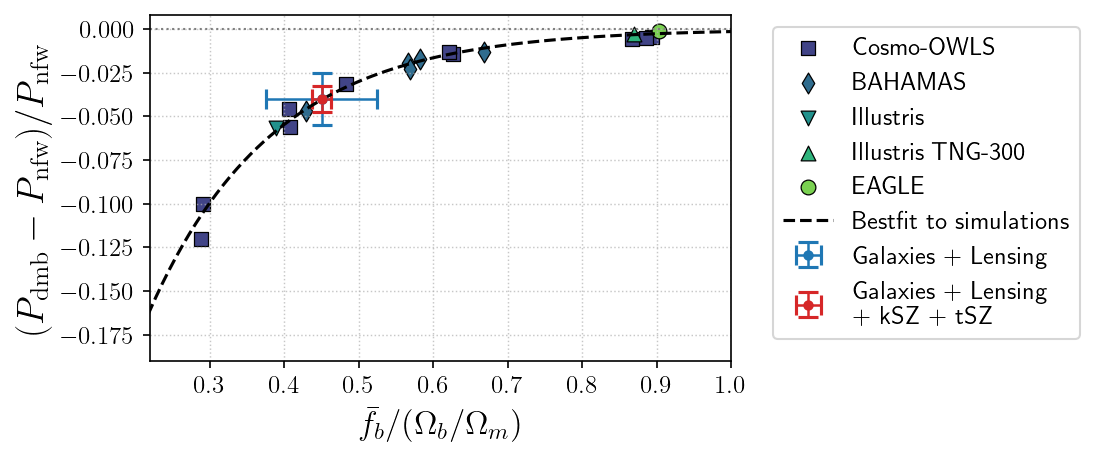

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5, 3), dpi=150)

# Improved error bars with better capsize and marker style
# shifts_fb = [0.075, 0.075, 0.075]
# fb_mean_plot = [0.36, 0.32]
# DeltaP_mean_plot = [-0.07, -0.086]
# colors = ['tab:red', 'tab:blue']
# labels = ['Galaxies + Lensing' + '\n' +  '+ tSZ + kSZ', 'Galaxies + Lensing']

# fb_mean_plot = [0.32, 0.37, 0.45]
# DeltaP_mean_plot = [ -0.086, -0.065, -0.04]
# colors = ['tab:blue', 'tab:orange', 'tab:red']
# labels = ['Galaxies + Lensing', 'Galaxies + Lensing' + '\n' +  '+ kSZ', 'Galaxies + Lensing' + '\n' +  '+ kSZ + tSZ']

fb_mean_plot = [0.45, 0.45]
DeltaP_mean_plot = [ -0.04, -0.04]
colors = ['tab:blue', 'tab:red']
labels = ['Galaxies + Lensing', 'Galaxies + Lensing' + '\n' +  '+ kSZ + tSZ']


for jp, probes_forecast in enumerate(probes_forecast_all):
    fb_mean = fb_mean_all['_'.join(probes_forecast.split(','))]
    fb_std = fb_std_all['_'.join(probes_forecast.split(','))]
    DeltaP_mean = DeltaP_mean_all['_'.join(probes_forecast.split(','))]
    DeltaP_std = DeltaP_std_all['_'.join(probes_forecast.split(','))]
    plt.errorbar(
        fb_mean_plot[jp], DeltaP_mean_plot[jp], 
        xerr=fb_std, yerr=DeltaP_std, 
        fmt='o', capsize=5, capthick=1.5, elinewidth=1.2, 
        label=labels[jp], color=colors[jp], markersize=4
    )

# # Define colors for different simulations
# colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(all_sims)))

# # Loop through simulations and plot them with improved markers
# for i, sim in enumerate(all_sims):
#     data_sim = np.array(sims_data[sim])
#     plt.scatter(
#         data_sim[:, 0], data_sim[:, 1], 
#         marker='s', s=40, color=colors[i], 
#         label=sim, edgecolor='black', linewidth=0.6
#     )
# Define different markers and colors for simulations
markers = ['s', 'd', 'v', '^', 'o', 'p', '*', 'X']  # Different marker types
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(all_sims)))

# Loop through simulations and plot them with distinct markers
for i, sim in enumerate(all_sims):
    data_sim = np.array(sims_data[sim])
    plt.scatter(
        data_sim[:, 0], data_sim[:, 1], 
        marker=markers[i % len(markers)], s=50, 
        color=colors[i], label=sim, 
        edgecolor='black', linewidth=0.6
    )

# van Daalen et al. 2019 curve
fb_array = np.linspace(0.2, 1.1, 100)
VD_curve = -1 * np.exp(-5.990 * fb_array - 0.5107)
# plt.plot(fb_array, VD_curve, ls='--', color='black', label='Daalen et al. 20', linewidth=1.5)
plt.plot(fb_array, VD_curve, ls='--', color='black', label='Bestfit to simulations', linewidth=1.5)

# Add horizontal reference line
plt.axhline(0.0, ls=':', color='gray', linewidth=1)

# Improve axis limits and labels
plt.xlim(0.22, 1.0)
plt.xlabel(r'$\bar{f}_b/(\Omega_b/\Omega_m)$', fontsize=16)
# plt.ylabel(r'$\Delta P$', fontsize=16)
plt.ylabel(r'$(P_{\rm dmb}-P_{\rm nfw})/P_{\rm nfw}$', fontsize=18)

# Improve legend
# plt.legend(fontsize=12, frameon=True, loc='best')
plt.legend(fontsize=12, frameon=True, bbox_to_anchor=(1.05, 1.0), loc='upper left')

# General plot aesthetics
plt.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'VD19_v10_widemuej.pdf', bbox_inches='tight', dpi=300 )
# plt.savefig(sdir + 'VD19_v12.pdf', bbox_inches='tight', dpi=300 )
plt.savefig('VD19_proposal_v3.pdf', bbox_inches='tight', dpi=300 )
plt.show()


